# CrediNode AI — Exploratory Data Analysis & Model Evaluation
### FIN-O-HACK | Paytm × ASSETS DTU

This notebook walks through:
1. Dataset exploration and distributions
2. Gate 1 (Isolation Forest) analysis
3. BSI feature correlation study
4. GNN topology visualization
5. Ensemble model comparison
6. SHAP waterfall plots
7. Score band calibration

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import networkx as nx
from pathlib import Path

from config.settings import PROCESSED_DIR, MODELS_DIR, SCORE_CONFIG

plt.style.use('dark_background')
ACCENT = '#00d4ff'
RED = '#ef4444'
GREEN = '#10b981'
YELLOW = '#f59e0b'

print('✓ Imports complete')

e:\credinode_ai\credinode\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete


## 1. Load & Explore the Synthetic Merchant Dataset

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'full_features.csv')
print(f'Shape: {df.shape}')
print(f'Ghost rate:   {df["is_ghost"].mean():.1%}')
print(f'Default rate: {df["is_default"].mean():.1%}')
df.head()

Shape: (10000, 33)
Ghost rate:   8.3%
Default rate: 13.6%


,merchant_id,is_ghost,is_default,business_age_days,merchant_category,merchant_category_name,city,city_tier,has_soundbox,qr_active,...,login_hour_entropy,transaction_velocity,unique_device_count,ip_change_frequency,weekend_activity_ratio,gnn_risk_score,neighbor_avg_default_rate,network_centrality,high_risk_neighbor_count,anomaly_score
0,M000000,0,0,313,1,Restaurant/Dhaba,Ahmedabad,2,1,1,...,0.5473,2.5716,2,0.8258,0.2293,0.2670,0.3333,0.0003,1,0.8103
1,M000001,0,0,313,2,Medical/Pharmacy,Varanasi,3,1,1,...,0.4466,1.3079,2,0.3514,0.1752,0.4522,0.4000,0.0010,4,0.7983
2,M000002,0,0,1844,3,Clothing/Textile,Chennai,1,1,1,...,0.5104,4.0254,2,0.5691,0.3415,0.0114,0.0000,0.0004,0,0.8162
3,M000003,0,0,840,4,Electronics,Surat,2,1,0,...,0.4428,5.2759,2,0.3427,0.2703,0.1889,0.0000,0.0005,0,0.7891
4,M000004,0,0,720,2,Medical/Pharmacy,Mumbai,1,0,1,...,0.4548,7.6233,1,1.1840,0.3118,0.2561,0.1250,0.0008,1,0.8724


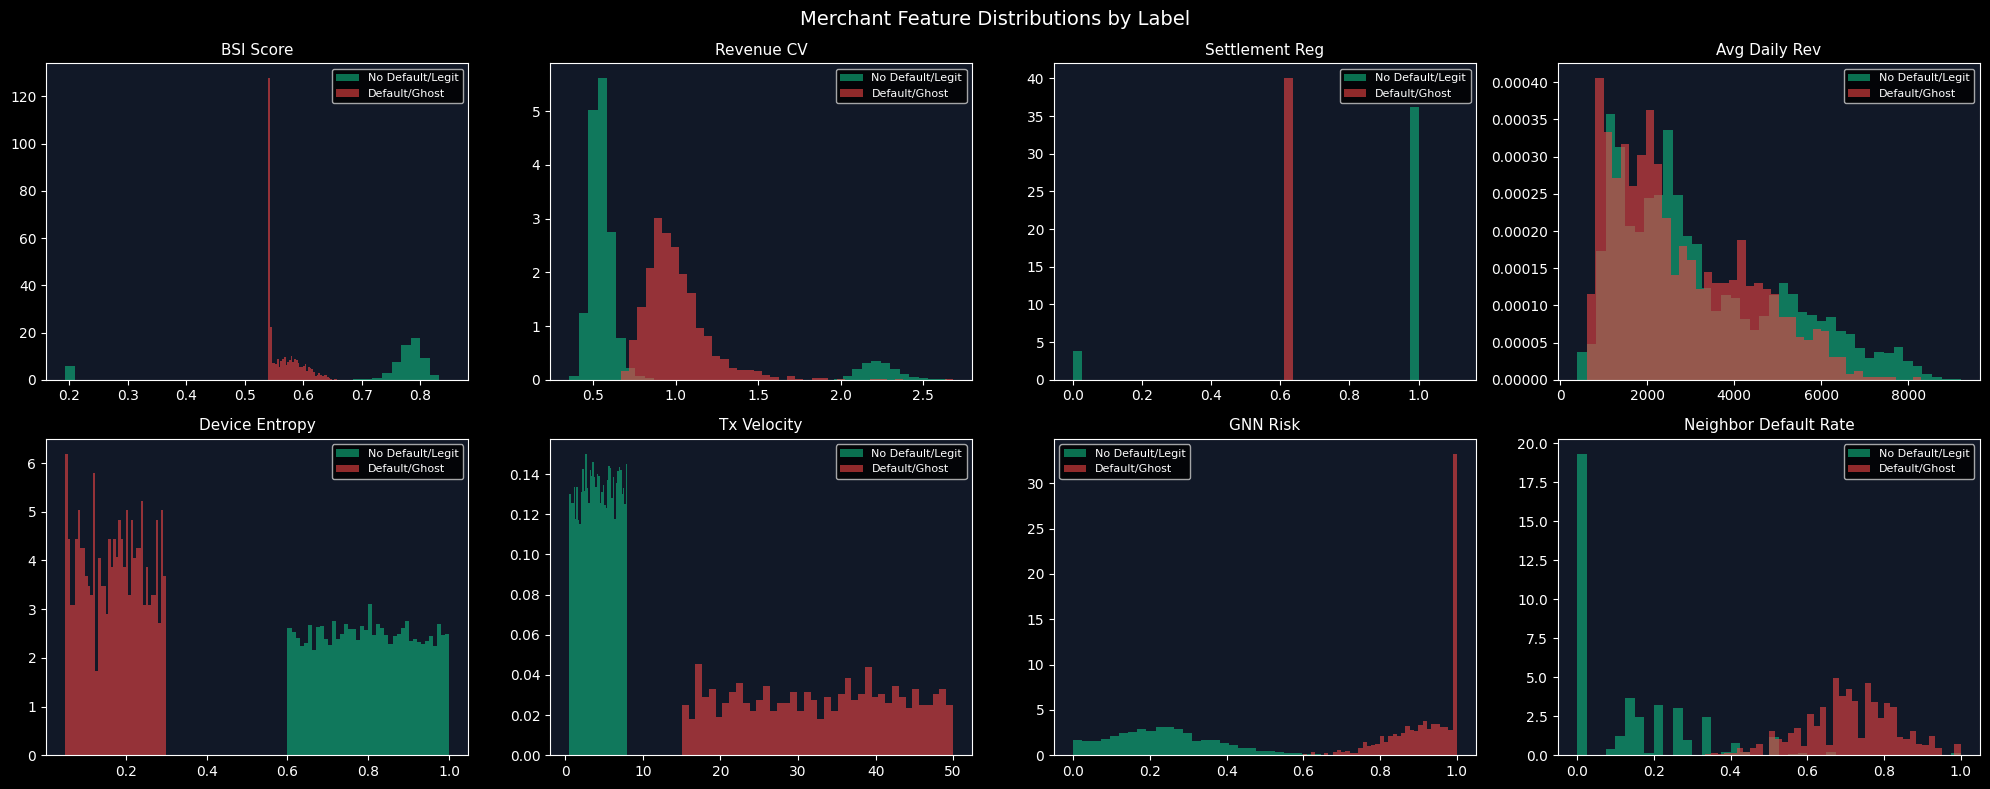

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Merchant Feature Distributions by Label', fontsize=14, color='white')

features_to_plot = [
    ('bsi_score', 'BSI Score'),
    ('revenue_cv', 'Revenue CV'),
    ('settlement_regularity', 'Settlement Reg'),
    ('avg_daily_revenue', 'Avg Daily Rev'),
    ('device_session_entropy', 'Device Entropy'),
    ('transaction_velocity', 'Tx Velocity'),
    ('gnn_risk_score', 'GNN Risk'),
    ('neighbor_avg_default_rate', 'Neighbor Default Rate'),
]

for (feat, title), ax in zip(features_to_plot, axes.flat):
    for label, color, name in [(0, GREEN, 'No Default/Legit'), (1, RED, 'Default/Ghost')]:
        col = 'is_ghost' if feat in ['device_session_entropy', 'transaction_velocity'] else 'is_default'
        vals = df[df[col] == label][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(title, color='white', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_facecolor('#111827')

plt.tight_layout()
plt.show()

## 2. Gate 1 — Isolation Forest Evaluation

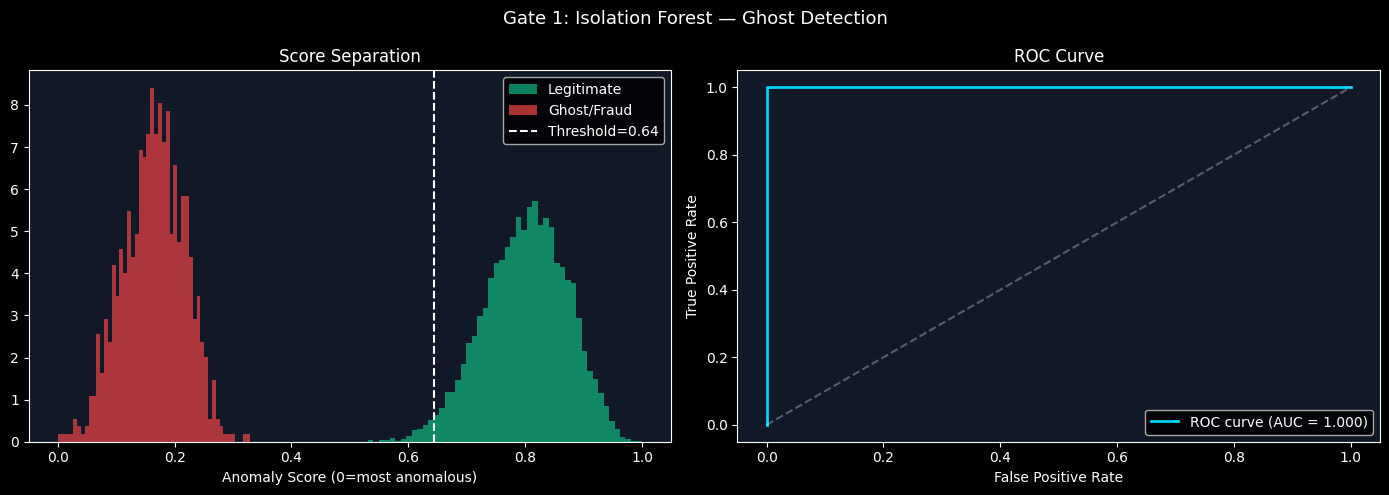

ROC-AUC: 1.0000


In [4]:
gate1 = joblib.load(MODELS_DIR / 'gate1_isolation_forest.joblib')
from config.settings import GATE1_FEATURES

X_g1 = df[GATE1_FEATURES].fillna(0)
X_scaled = gate1['scaler'].transform(X_g1)
raw_scores = gate1['model'].score_samples(X_scaled)
anomaly_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gate 1: Isolation Forest — Ghost Detection', fontsize=13)

ax = axes[0]
ax.hist(anomaly_scores[df['is_ghost']==0], bins=50, alpha=0.7, color=GREEN, label='Legitimate', density=True)
ax.hist(anomaly_scores[df['is_ghost']==1], bins=50, alpha=0.7, color=RED, label='Ghost/Fraud', density=True)
ax.axvline(gate1['threshold'], color='white', linestyle='--', label=f'Threshold={gate1["threshold"]:.2f}')
ax.set_xlabel('Anomaly Score (0=most anomalous)')
ax.set_title('Score Separation')
ax.legend()
ax.set_facecolor('#111827')

ax = axes[1]
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(df['is_ghost'], 1 - anomaly_scores)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color=ACCENT, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], 'w--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.set_facecolor('#111827')

plt.tight_layout()
plt.show()
print(f'ROC-AUC: {roc_auc:.4f}')

## 3. BSI Score vs Default Rate

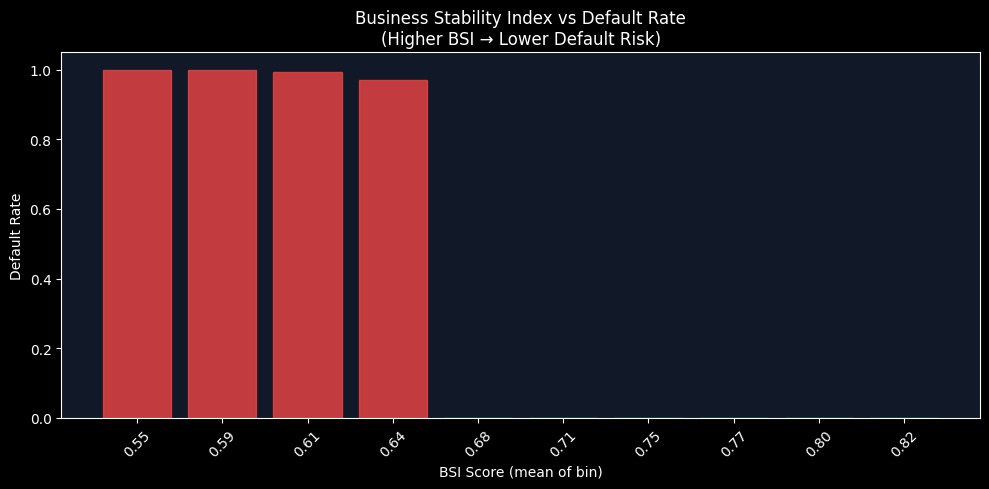

In [5]:
df_legit = df[df['is_ghost'] == 0].copy()

bins = pd.cut(df_legit['bsi_score'], bins=10)
default_rate = df_legit.groupby(bins, observed=False)['is_default'].mean()
bsi_means = df_legit.groupby(bins, observed=False)['bsi_score'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(default_rate)), default_rate.values, color=ACCENT, alpha=0.8, edgecolor='none')

# Color by risk level
for bar, val in zip(bars, default_rate.values):
    if val > 0.25: bar.set_color(RED)
    elif val > 0.12: bar.set_color(YELLOW)
    else: bar.set_color(GREEN)

ax.set_xticks(range(len(bsi_means)))
ax.set_xticklabels([f'{v:.2f}' for v in bsi_means.values], rotation=45)
ax.set_xlabel('BSI Score (mean of bin)')
ax.set_ylabel('Default Rate')
ax.set_title('Business Stability Index vs Default Rate\n(Higher BSI → Lower Default Risk)', fontsize=12)
ax.set_facecolor('#111827')
plt.tight_layout()
plt.show()

## 4. Network Graph Visualization

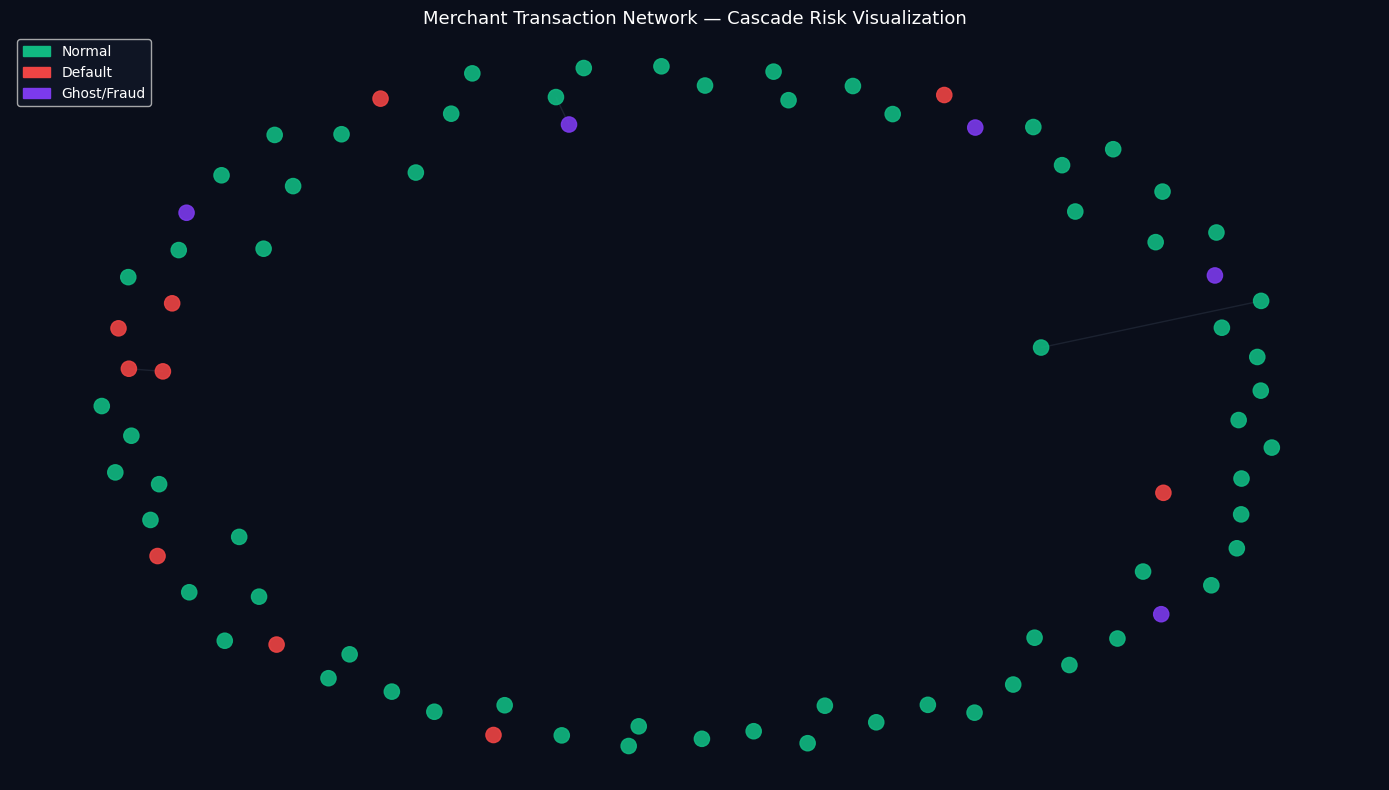

Nodes: 80 | Edges: 3


In [6]:
edges = pd.read_csv(PROCESSED_DIR / 'graph_edges.csv')
merchants = pd.read_csv(PROCESSED_DIR / 'merchants.csv')

# Build a small subgraph for visualization
sample_merchants = merchants.sample(80, random_state=42)['merchant_id'].values
sample_edges = edges[
    edges['src'].isin(sample_merchants) & edges['dst'].isin(sample_merchants)
].head(200)

G = nx.DiGraph()
G.add_nodes_from(sample_merchants)
for _, row in sample_edges.iterrows():
    G.add_edge(row['src'], row['dst'], weight=row['weight'])

# Node colors based on default status
default_set = set(merchants[merchants['is_default']==1]['merchant_id'])
ghost_set   = set(merchants[merchants['is_ghost']==1]['merchant_id'])

colors = []
for node in G.nodes():
    if node in ghost_set: colors.append('#7c3aed')
    elif node in default_set: colors.append(RED)
    else: colors.append(GREEN)

plt.figure(figsize=(14, 8), facecolor='#0a0e1a')
ax = plt.gca()
ax.set_facecolor('#0a0e1a')

pos = nx.spring_layout(G, k=1.5, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=120, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='#64748b', arrows=False, ax=ax)

from matplotlib.patches import Patch
legend = [Patch(color=GREEN, label='Normal'), Patch(color=RED, label='Default'),
          Patch(color='#7c3aed', label='Ghost/Fraud')]
plt.legend(handles=legend, loc='upper left', facecolor='#111827', labelcolor='white')
plt.title('Merchant Transaction Network — Cascade Risk Visualization', color='white', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}')

## 5. Gate 3 — SHAP Waterfall Plot

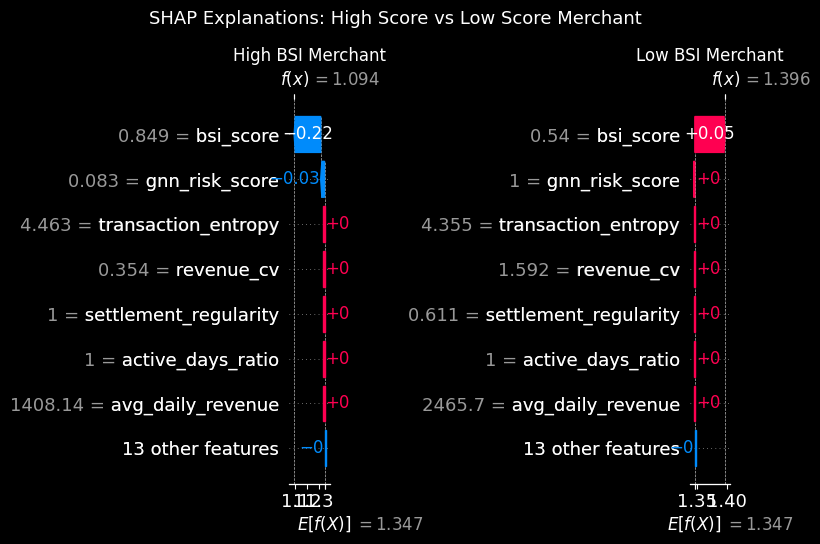

In [7]:
try:
    xgb_model = joblib.load(MODELS_DIR / 'gate3_xgb.joblib')
    shap_explainer = joblib.load(MODELS_DIR / 'gate3_shap_explainer.joblib')
    meta = joblib.load(MODELS_DIR / 'gate3_meta.joblib')
    
    from config.settings import ENSEMBLE_FEATURES
    df_legit = df[df['is_ghost']==0].copy()
    df_legit['merchant_category_encoded'] = df_legit['merchant_category']
    X = df_legit[ENSEMBLE_FEATURES].fillna(0)
    
    # Pick a specific merchant to explain
    high_score_idx = df_legit['bsi_score'].idxmax()
    low_score_idx  = df_legit['bsi_score'].idxmin()
    
    shap_values = shap_explainer.shap_values(X)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('SHAP Explanations: High Score vs Low Score Merchant', fontsize=13)
    
    for ax, idx, title in [
        (axes[0], df_legit.index.get_loc(high_score_idx), 'High BSI Merchant'),
        (axes[1], df_legit.index.get_loc(low_score_idx), 'Low BSI Merchant'),
    ]:
        plt.sca(ax)
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[idx],
                base_values=shap_explainer.expected_value,
                data=X.iloc[idx].values,
                feature_names=ENSEMBLE_FEATURES
            ),
            show=False, max_display=8
        )
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print('Train models first: run scripts 03-06, then come back here!')

## 6. CrediNode Score Distribution

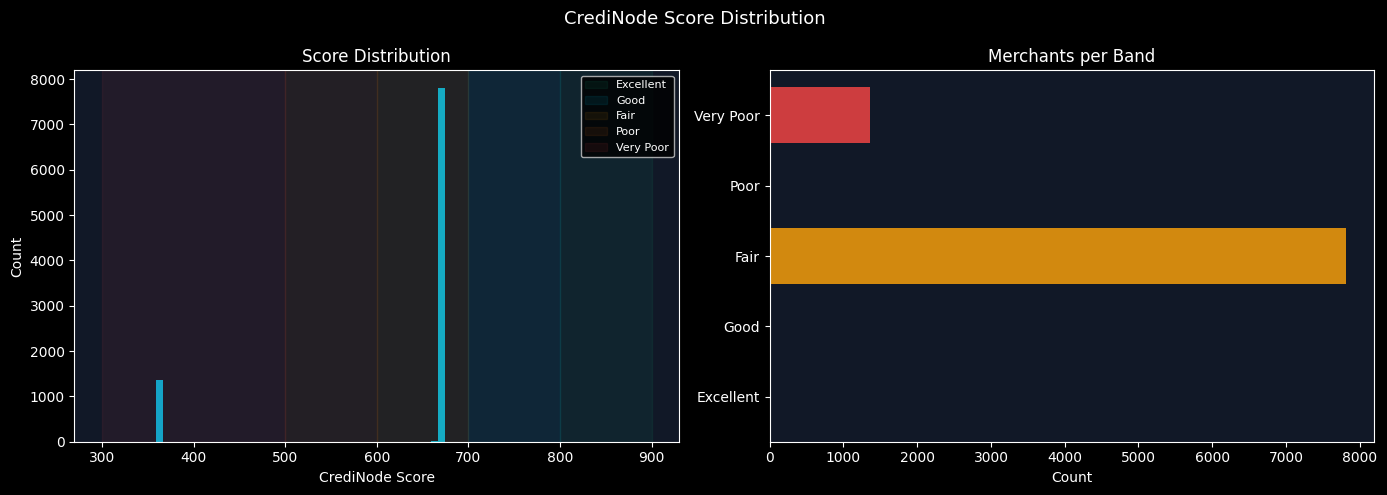

Mean Score: 628 | Median: 675


In [8]:
try:
    xgb_model = joblib.load(MODELS_DIR / 'gate3_xgb.joblib')
    lgbm_model = joblib.load(MODELS_DIR / 'gate3_lgbm.joblib')
    meta = joblib.load(MODELS_DIR / 'gate3_meta.joblib')

    df_legit = df[df['is_ghost']==0].copy()
    df_legit['merchant_category_encoded'] = df_legit['merchant_category']
    X = df_legit[meta['feature_names']].fillna(0)

    p_xgb = xgb_model.predict_proba(X)[:, 1]
    p_lgbm = lgbm_model.predict_proba(X)[:, 1]
    probs = 0.5 * p_xgb + 0.5 * p_lgbm

    scores = (900 - probs * 600).clip(300, 900).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('CrediNode Score Distribution', fontsize=13)

    ax = axes[0]
    colors_hist = ['#10b981' if s >= 800 else '#00d4ff' if s >= 700 else
                   '#f59e0b' if s >= 600 else '#f97316' if s >= 500 else '#ef4444'
                   for s in scores]
    ax.hist(scores, bins=40, color=ACCENT, alpha=0.8, edgecolor='none')
    for lo, hi, c, label in [
        (800,900,'#10b981','Excellent'),(700,800,'#00d4ff','Good'),
        (600,700,'#f59e0b','Fair'),(500,600,'#f97316','Poor'),(300,500,'#ef4444','Very Poor')
    ]:
        ax.axvspan(lo, hi, alpha=0.08, color=c, label=label)
    ax.set_xlabel('CrediNode Score')
    ax.set_ylabel('Count')
    ax.set_title('Score Distribution')
    ax.legend(fontsize=8)
    ax.set_facecolor('#111827')

    ax = axes[1]
    bands = ['Excellent','Good','Fair','Poor','Very Poor']
    limits = [800, 700, 600, 500, 300]
    counts = [((scores >= lo) & (scores < hi)).sum() 
              for (lo, hi) in [(800,901),(700,800),(600,700),(500,600),(300,500)]]
    bar_colors = ['#10b981','#00d4ff','#f59e0b','#f97316','#ef4444']
    ax.barh(bands, counts, color=bar_colors, alpha=0.85)
    ax.set_xlabel('Count')
    ax.set_title('Merchants per Band')
    ax.set_facecolor('#111827')

    plt.tight_layout()
    plt.show()
    print(f'Mean Score: {scores.mean():.0f} | Median: {np.median(scores):.0f}')

except FileNotFoundError:
    print('Train models first!')